In [7]:
# Import required libraries
import cv2

# Create an animation to visualize the results
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML
from matplotlib import pyplot as plt

%matplotlib inline

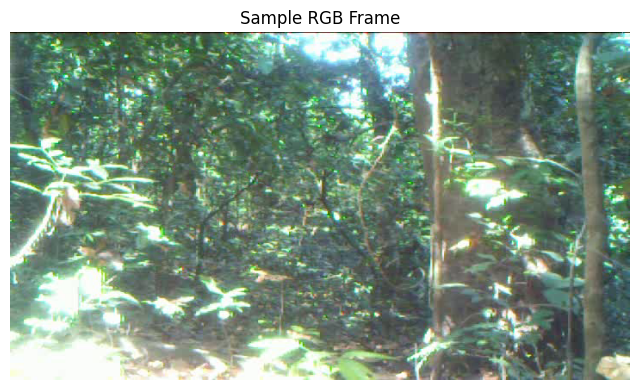

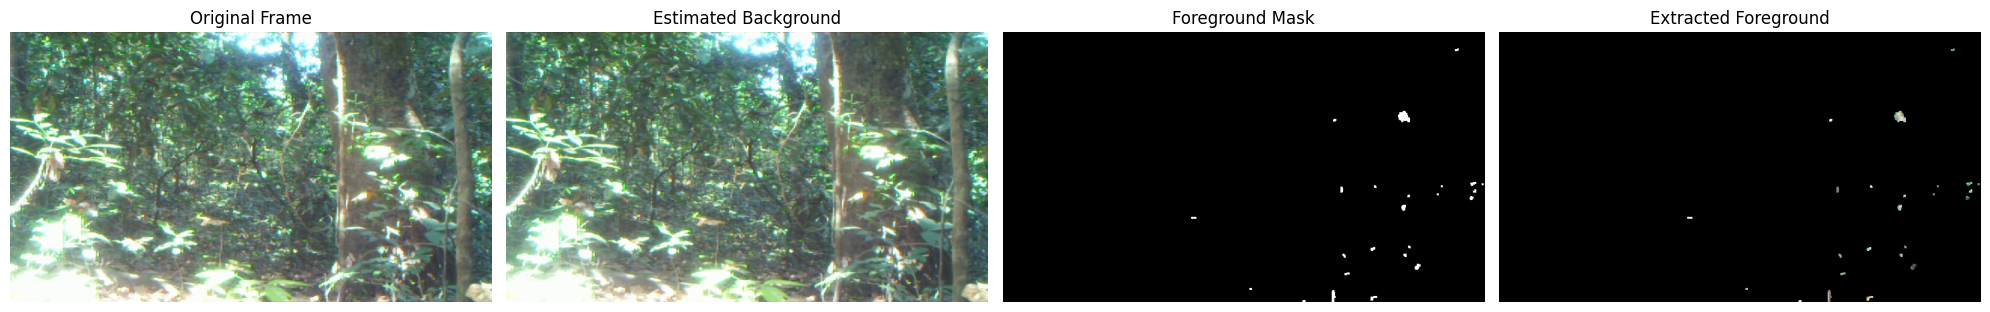

Animation size has reached 21063330 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


In [ ]:
# load the video
video = "/home/kukushkin/imslowfast/dataset/videos/32375837.mp4"
video = "/home/kukushkin/imslowfast/dataset/videos/32375837.mp4"


# Create sample video frames
frames = []

cap = cv2.VideoCapture(video)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frames.append(frame)

cap.release()


# Display a sample frame
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB))
plt.title("Sample RGB Frame")
plt.axis("off")
plt.show()


# Function to perform background subtraction using median filter for RGB video
def median_background_subtraction_rgb(frames, threshold=30):
    # Calculate median background for each channel
    background = np.median(frames, axis=0).astype(np.uint8)

    # Perform background subtraction on each frame
    foreground_masks = []
    foreground_frames = []

    for frame in frames:
        # Calculate absolute difference for each channel
        diff = cv2.absdiff(frame, background)

        # Convert difference to grayscale for thresholding
        diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

        # Apply threshold
        _, mask = cv2.threshold(diff_gray, threshold, 255, cv2.THRESH_BINARY)

        # Optional: Apply morphological operations to clean up the mask
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Create 3-channel mask for color preservation
        mask_3channel = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

        # Extract foreground
        foreground = cv2.bitwise_and(frame, mask_3channel)

        foreground_masks.append(mask)
        foreground_frames.append(foreground)

    return background, foreground_masks, foreground_frames


# Perform background subtraction
background, foreground_masks, foreground_frames = median_background_subtraction_rgb(
    frames
)

# Display results
plt.figure(figsize=(20, 5))

plt.subplot(141)
plt.imshow(cv2.cvtColor(frames[25], cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")

plt.subplot(142)
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.title("Estimated Background")
plt.axis("off")

plt.subplot(143)
plt.imshow(foreground_masks[25], cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.subplot(144)
plt.imshow(cv2.cvtColor(foreground_frames[25], cv2.COLOR_BGR2RGB))
plt.title("Extracted Foreground")
plt.axis("off")

plt.tight_layout()
plt.show()


# Function to process video file
def process_video_file(video_path, sample_rate=1):
    """
    Process a video file for background subtraction
    sample_rate: process every nth frame (1 = all frames)
    """
    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened():
        for _ in range(sample_rate):
            ret, _ = cap.read()  # Skip frames according to sample_rate
            if not ret:
                break

        ret, frame = cap.read()
        if not ret:
            break

        frames.append(frame)

    cap.release()
    return frames


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))


def animate(i):
    ax1.clear()
    ax2.clear()
    ax3.clear()

    # Original frame
    ax1.imshow(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Frame")
    ax1.axis("off")

    # Foreground mask
    ax2.imshow(foreground_masks[i], cmap="gray")
    ax2.set_title("Foreground Mask")
    ax2.axis("off")

    # Extracted foreground
    ax3.imshow(cv2.cvtColor(foreground_frames[i], cv2.COLOR_BGR2RGB))
    ax3.set_title("Extracted Foreground")
    ax3.axis("off")

    return ax1, ax2, ax3


anim = animation.FuncAnimation(
    fig, animate, frames=len(frames), interval=100, blit=False
)
plt.close()

# Display the animation in the notebook
HTML(anim.to_jshtml())

# Example usage with a video file
"""
# Uncomment and modify path to use with your video file
video_frames = process_video_file('path_to_your_video.mp4', sample_rate=2)
background, masks, foregrounds = median_background_subtraction_rgb(video_frames)
"""


# Optional: Save processed video
def save_processed_video(output_path, frames, fps=30):
    """
    Save processed frames as a video file
    """
    height, width = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    for frame in frames:
        out.write(frame)

    out.release()